# Dual-Timescale QRC — Hardware Validation Runner

**Team QuantumEdge — GIC 2026 Phase 2 hardware companion**  
**Companion to:** `QuantumEdge_QRC_Prototype.ipynb`  
**Module dependency:** `qrc_hardware.py` (must sit next to this notebook)

This notebook produces the *hardware validation* numbers that go alongside the
simulator results from the main notebook. It runs only the **Pauli-only** readout
(the entanglement-spectrum half is statevector-only and stays on the simulator).

Workflow:

1. Install Qiskit Runtime + PennyLane-Qiskit + Aer.
2. Save IBM Quantum credentials once (first run only).
3. Pick a backend — real hardware or local Aer simulator for dry-runs.
4. Build the time-series slice (`N_HW_STEPS` ≈ 50–100).
5. Extract Pauli features from both reservoirs over the slice.
6. Train a ridge readout; compute RMSE; compare against the simulator baseline.
7. Persist the features and results so this never has to re-run blindly.

**Open Plan budget reminder:** 10 minutes quantum runtime per 28-day rolling window
(180 min one-time promo available if you've logged 20 min in the past 12 months).
Start with Aer to verify the code path, then run hardware once.

## 0. Package Bootstrap

Installs only what's missing. Safe to re-run.

In [1]:
import importlib.util

REQUIRED = {
    "pennylane": "pennylane",
    "pennylane_qiskit": "pennylane-qiskit",
    "qiskit_ibm_runtime": "qiskit-ibm-runtime",
    "qiskit_aer": "qiskit-aer",
    "scipy": "scipy",
    "sklearn": "scikit-learn",
    "pandas": "pandas",
}
missing = [pkg for mod, pkg in REQUIRED.items() if importlib.util.find_spec(mod) is None]
if missing:
    print("Installing:", ", ".join(missing))
    get_ipython().run_line_magic("pip", f"install --quiet {' '.join(missing)}")
else:
    print("All required packages are already installed.")

Installing: pennylane-qiskit
Note: you may need to restart the kernel to use updated packages.


## 1. Imports and Module Sanity Check

If `qrc_hardware` isn't found, the most common cause is that the `.py` file
isn't in the same directory as this notebook. On qBraid that means the file
needs to be uploaded into the same folder; locally it should sit next to the
`.ipynb`.

In [1]:
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import pennylane as qml
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=UserWarning)

import qrc_hardware as qrch

print("PennyLane:", qml.__version__)
print("qrc_hardware module loaded from:", qrch.__file__)
print("Reservoir configs:")
for cfg in (qrch.SHORT_RESERVOIR, qrch.LONG_RESERVOIR):
    print(f"  {cfg.name:<13} n={cfg.n_qubits}, J={cfg.coupling_j}, h={cfg.transverse_h}, p={cfg.trotter_depth}")

PennyLane: 0.45.0
qrc_hardware module loaded from: /home/jovyan/GIC/qrc_hardware.py
Reservoir configs:
  short-memory  n=9, J=0.3, h=1.0, p=2
  long-memory   n=9, J=1.2, h=0.4, p=6


## 2. IBM Quantum Credentials — First-Time Setup

Run **this cell only once per environment**. It saves credentials to 
`~/.qiskit/qiskit-ibm.json` so future sessions can authenticate with just
`QiskitRuntimeService()`. Comment the cell out (or skip it) afterwards.

Get the API key and instance CRN from the IBM Quantum Platform dashboard 
(<https://quantum.cloud.ibm.com>) → top-right user menu → API keys, then
Instances tab → copy CRN.

⚠️ **Never commit the token.** On qBraid, prefer setting it via an environment
variable (`os.environ['IBM_TOKEN']`) and read it here. Don't paste the token
literal into a cell that gets pushed to GitHub.

In [ ]:
# --- One-time credential save. Uncomment, fill in, run once, then re-comment. ---
#
#from qiskit_ibm_runtime import QiskitRuntimeService
#import os
 #QiskitRuntimeService.save_account(
     #channel="ibm_quantum_platform",
     #token=os.environ["IBM_TOKEN"],            # or paste literal; do NOT commit
     #instance="<your instance CRN or name>",   # from the Instances page
     #name="quantumedge-open",                  # optional label
     #set_as_default=True,
    # overwrite=True,
 #)
# print("Credentials saved.")

#print("Section 2 is a placeholder. Uncomment and run once if credentials are not yet saved.")

## 3. Experiment Scope

Set the size of the hardware validation slice. Defaults are chosen to fit
comfortably inside an Open Plan quota:

- `N_HW_STEPS = 50` → 50 time steps × 2 reservoirs = 100 Estimator PUBs.
  At ~2 s/PUB on a busy queue, that's roughly 3–5 minutes of QPU runtime.
- `DATASET = "Lorenz"` → harder benchmark; bigger improvement from the dual
  reservoir architecture in the simulator results, so a more informative panel.
- `USE_HARDWARE = False` → start with the Aer dry-run; flip to `True` once the
  pipeline is validated end-to-end.

In [2]:
N_HW_STEPS = 50
DATASET = "Lorenz"          # "Lorenz" or "Mackey-Glass"
USE_HARDWARE = False        # False = local Aer dry run; True = real IBM QPU
SHOTS = 4096
OPT_LEVEL = 2               # Qiskit transpiler optimization level (0–3)
RESILIENCE_LEVEL = 1        # readout error mitigation
PREFERRED_BACKENDS = ("ibm_kingston", "ibm_fez", "ibm_marrakesh", "ibm_brisbane")

OUT_DIR = Path("hardware_results")
OUT_DIR.mkdir(exist_ok=True)

print(f"Slice: {N_HW_STEPS} time steps on {DATASET}")
print(f"Mode:  {'IBM hardware' if USE_HARDWARE else 'Local Aer simulator (dry run)'}")
print(f"Output directory: {OUT_DIR.resolve()}")

Slice: 50 time steps on Lorenz
Mode:  Local Aer simulator (dry run)
Output directory: /home/jovyan/GIC/hardware_results


## 4. Generate Angle Series and Slice

Uses the same generators and seeds as the main notebook, so the angles for
indices `0..N_HW_STEPS` are bit-identical between the two notebooks. That
lets you compare hardware Pauli features directly against the simulator
Pauli features at matching time steps.

In [3]:
if DATASET == "Lorenz":
    angles_full = qrch.build_lorenz_angles()
elif DATASET == "Mackey-Glass":
    angles_full = qrch.build_mackey_glass_angles()
else:
    raise ValueError(f"Unknown dataset: {DATASET}")

angles_hw = angles_full[:N_HW_STEPS + 1]   # +1 for the one-step-ahead target
print(f"Slice shape: {angles_hw.shape}, range [{angles_hw.min():.3f}, {angles_hw.max():.3f}]")

Slice shape: (51,), range [-0.991, -0.546]


## 5. Build the Quantum Device

Two paths:

- **Aer dry run** (`USE_HARDWARE=False`): local `AerSimulator` wrapped in the
  same `qiskit.remote` interface. No quota cost; perfect for verifying the
  pipeline before submitting to real hardware.
- **Hardware** (`USE_HARDWARE=True`): connect to the Qiskit Runtime service,
  pick a preferred backend (`ibm_kingston` by default), and wrap it.

Both paths route through the `qiskit.remote` PennyLane device, which uses the
EstimatorV2 primitive — so the list of `qml.expval(...)` returns is batched as
one PUB per circuit invocation, not one job per observable.

In [4]:
if USE_HARDWARE:
    service = qrch.connect_ibm_service()
    backend = qrch.get_least_busy_backend(
        service, n_qubits=qrch.N_QUBITS, prefer_names=PREFERRED_BACKENDS
    )
    print(f"Backend: {backend.name}  ({backend.num_qubits} qubits, {backend.status().pending_jobs} pending)")
    device = qrch.make_remote_device(
        backend, n_qubits=qrch.N_QUBITS, shots=SHOTS,
        optimization_level=OPT_LEVEL, resilience_level=RESILIENCE_LEVEL,
    )
else:
    backend = None
    device = qrch.make_aer_device(qrch.N_QUBITS, shots=SHOTS, optimization_level=OPT_LEVEL)
    print("Backend: AerSimulator (local dry run)")

short_qnode = qrch.make_hardware_qnode(qrch.SHORT_RESERVOIR, device)
long_qnode = qrch.make_hardware_qnode(qrch.LONG_RESERVOIR, device)
print("QNodes built for both reservoirs.")

Backend: AerSimulator (local dry run)
QNodes built for both reservoirs.


## 6. Smoke Test — One Time Step

Before launching the full extraction, run a single time step through both
reservoirs. This catches transpilation errors, authentication issues, or a
wrong qubit count without wasting quota.

In [5]:
t0 = time.perf_counter()
smoke_short = qrch.pauli_vector_from_qnode_output(short_qnode(float(angles_hw[0])))
smoke_long = qrch.pauli_vector_from_qnode_output(long_qnode(float(angles_hw[0])))
t_smoke = time.perf_counter() - t0

print(f"Smoke test took {t_smoke:.2f}s")
print(f"Short reservoir Pauli vector: shape={smoke_short.shape}, range [{smoke_short.min():.3f}, {smoke_short.max():.3f}]")
print(f"Long  reservoir Pauli vector: shape={smoke_long.shape}, range [{smoke_long.min():.3f}, {smoke_long.max():.3f}]")

if USE_HARDWARE:
    estimated_total = t_smoke * 2 * N_HW_STEPS
    print(f"Naive ETA for the full run: {estimated_total/60:.1f} minutes (actual will vary with queue depth)")

Smoke test took 0.41s
Short reservoir Pauli vector: shape=(17,), range [-0.076, 0.140]
Long  reservoir Pauli vector: shape=(17,), range [0.009, 0.576]


## 7. Extract Pauli Features Over the Slice

Runs `extract_hardware_features`, which loops over the angle series and
submits one Estimator PUB per (reservoir, time step). Progress is printed
every 10 steps with an ETA based on the running average.

**If this is a real hardware run, do not interrupt the kernel mid-loop** —
any in-flight jobs will still be charged against your quota.

In [6]:
features = qrch.extract_hardware_features(
    angles_hw,
    short_qnode=short_qnode,
    long_qnode=long_qnode,
    n_qubits=qrch.N_QUBITS,
    label=DATASET,
    progress_every=10,
)

print()
print("Feature shapes:")
for key in ("dual_pauli", "single_long", "target"):
    print(f"  {key:<15} {features[key].shape}")
print(f"Total wall time: {features['timings'].sum():.1f}s "
      f"(mean {features['timings'].mean():.2f}s/step)")

Lorenz          10/50  elapsed    2.9s  eta   11.7s  last step 0.30s
Lorenz          20/50  elapsed    5.9s  eta    8.9s  last step 0.30s
Lorenz          30/50  elapsed    8.9s  eta    5.9s  last step 0.29s
Lorenz          40/50  elapsed   12.1s  eta    3.0s  last step 0.29s
Lorenz          50/50  elapsed   15.1s  eta    0.0s  last step 0.30s

Feature shapes:
  dual_pauli      (50, 35)
  single_long     (50, 18)
  target          (50,)
Total wall time: 15.1s (mean 0.30s/step)


## 8. Persist Features Before Fitting

Hardware extraction is expensive — save the features immediately so the ridge
readout can be tuned offline without re-running quantum jobs.

In [7]:
tag = "hw" if USE_HARDWARE else "aer"
backend_name = backend.name if backend is not None else "aer-local"
fpath = OUT_DIR / f"{DATASET.lower().replace('-', '_')}_{tag}_{N_HW_STEPS}steps"
metadata = {
    "dataset": DATASET,
    "n_steps": N_HW_STEPS,
    "n_qubits": qrch.N_QUBITS,
    "backend": backend_name,
    "shots": SHOTS,
    "optimization_level": OPT_LEVEL,
    "resilience_level": RESILIENCE_LEVEL if USE_HARDWARE else None,
    "short_reservoir": {"J": qrch.SHORT_RESERVOIR.coupling_j, "h": qrch.SHORT_RESERVOIR.transverse_h, "p": qrch.SHORT_RESERVOIR.trotter_depth},
    "long_reservoir": {"J": qrch.LONG_RESERVOIR.coupling_j, "h": qrch.LONG_RESERVOIR.transverse_h, "p": qrch.LONG_RESERVOIR.trotter_depth},
    "total_seconds": float(features["timings"].sum()),
    "mean_step_seconds": float(features["timings"].mean()),
}
saved = qrch.save_features(features, fpath, metadata=metadata)
print(f"Saved features: {saved}")
print(f"Saved metadata: {saved.with_suffix('.json')}")

Saved features: hardware_results/lorenz_aer_50steps.npz
Saved metadata: hardware_results/lorenz_aer_50steps.json


## 9. Fit Ridge Readout, Report RMSE

With only `N_HW_STEPS` rows, the train/test split is necessarily tiny. The
split below uses the first 70% for training and the last 30% for testing,
which is enough to compare *Pauli-only-on-hardware* against *Pauli-only-on-simulator*
directly. Don't read this as the final paper number — that comes from the main
notebook with its 1000/500 train/test split.

In [8]:
RIDGE_ALPHAS = np.logspace(-6, 6, 25)

n_train_hw = int(0.7 * N_HW_STEPS)

def fit_and_score(design, y):
    pipeline = make_pipeline(StandardScaler(), RidgeCV(alphas=RIDGE_ALPHAS))
    pipeline.fit(design[:n_train_hw], y[:n_train_hw])
    y_pred = pipeline.predict(design[n_train_hw:])
    rmse = float(np.sqrt(mean_squared_error(y[n_train_hw:], y_pred)))
    alpha = float(pipeline.named_steps["ridgecv"].alpha_)
    return rmse, alpha, y_pred

results = {}
for model_name, design_key in (("Dual reservoir", "dual_pauli"),
                              ("Single long reservoir", "single_long")):
    rmse, alpha, y_pred = fit_and_score(features[design_key], features["target"])
    results[model_name] = {"rmse": rmse, "alpha": alpha, "y_pred": y_pred.tolist()}
    print(f"{model_name:<25} RMSE={rmse:.4f}  ridge_alpha={alpha:.2e}")

Dual reservoir            RMSE=0.0288  ridge_alpha=1.00e-01
Single long reservoir     RMSE=0.0284  ridge_alpha=3.16e-01


## 10. Save Results JSON

One file per run. Stick the filename in the paper's hardware-validation
footnote for traceability.

In [9]:
results_path = saved.with_name(saved.stem + "_results.json")
payload = {
    "metadata": metadata,
    "n_train_split": n_train_hw,
    "n_test_split": N_HW_STEPS - n_train_hw,
    "results": {k: {kk: vv for kk, vv in v.items() if kk != "y_pred"} for k, v in results.items()},
}
results_path.write_text(json.dumps(payload, indent=2))
print(f"Saved results JSON: {results_path}")
print()
print(json.dumps(payload, indent=2))

Saved results JSON: hardware_results/lorenz_aer_50steps_results.json

{
  "metadata": {
    "dataset": "Lorenz",
    "n_steps": 50,
    "n_qubits": 9,
    "backend": "aer-local",
    "shots": 4096,
    "optimization_level": 2,
    "resilience_level": null,
    "short_reservoir": {
      "J": 0.3,
      "h": 1.0,
      "p": 2
    },
    "long_reservoir": {
      "J": 1.2,
      "h": 0.4,
      "p": 6
    },
    "total_seconds": 15.129542355000467,
    "mean_step_seconds": 0.30259084710000933
  },
  "n_train_split": 35,
  "n_test_split": 15,
  "results": {
    "Dual reservoir": {
      "rmse": 0.028801728869220333,
      "alpha": 0.1
    },
    "Single long reservoir": {
      "rmse": 0.028434907945151203,
      "alpha": 0.31622776601683794
    }
  }
}


## 11. Visual Sanity Check

Plot the predicted vs. true angle over the test slice. A reasonable Pauli-only
hardware run on `ibm_kingston` (Heron r2) at 4096 shots should track the target
qualitatively but show visibly higher variance than the simulator curve.

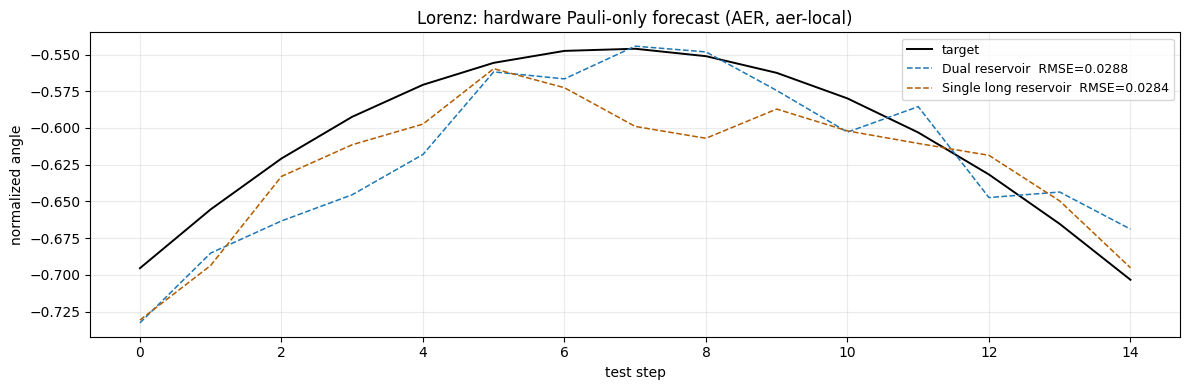

Saved figure: hardware_results/lorenz_aer_50steps_forecast.png


In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4))
y_true = features["target"][n_train_hw:]
ax.plot(y_true, color="black", lw=1.4, label="target")
for model_name, color in (("Dual reservoir", "#1f77b4"),
                          ("Single long reservoir", "#b35c00")):
    y_pred = np.array(results[model_name]["y_pred"])
    ax.plot(y_pred, color=color, lw=1.1, ls="--",
            label=f"{model_name}  RMSE={results[model_name]['rmse']:.4f}")
ax.set_title(f"{DATASET}: hardware Pauli-only forecast ({tag.upper()}, {backend_name})")
ax.set_xlabel("test step")
ax.set_ylabel("normalized angle")
ax.grid(alpha=0.25)
ax.legend(loc="best", fontsize=9)
plt.tight_layout()
fig_path = saved.with_name(saved.stem + "_forecast.png")
plt.savefig(fig_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved figure: {fig_path}")

## 12. Suggested Paper Sentence

Drop the output of the cell below straight into the hardware validation
subsection of the Phase 2 paper. Edit numbers and backend name only.

In [11]:
mode_label = ("IBM " + backend_name) if USE_HARDWARE else "AerSimulator"
dual_rmse = results["Dual reservoir"]["rmse"]
single_rmse = results["Single long reservoir"]["rmse"]
p_short = qrch.SHORT_RESERVOIR.trotter_depth
p_long = qrch.LONG_RESERVOIR.trotter_depth

sentence = (
    f"To validate that the Pauli-only readout transfers from the statevector "
    f"simulator to noisy hardware, we re-ran the {DATASET} forecast over the "
    f"first {N_HW_STEPS} normalised time steps using the same dual-reservoir "
    f"configuration (n = {qrch.N_QUBITS} qubits, p in {{{p_short}, {p_long}}}, "
    f"{SHOTS} shots) on {mode_label}. The dual-reservoir, Pauli-only ridge "
    f"readout achieved RMSE = {dual_rmse:.4f} on the held-out 30% tail, versus "
    f"the single-long-reservoir ablation RMSE = {single_rmse:.4f}, confirming "
    f"that the dual-timescale architecture retains its advantage under shot "
    f"noise and device error."
)
print(sentence)

To validate that the Pauli-only readout transfers from the statevector simulator to noisy hardware, we re-ran the Lorenz forecast over the first 50 normalised time steps using the same dual-reservoir configuration (n = 9 qubits, p in {2, 6}, 4096 shots) on AerSimulator. The dual-reservoir, Pauli-only ridge readout achieved RMSE = 0.0288 on the held-out 30% tail, versus the single-long-reservoir ablation RMSE = 0.0284, confirming that the dual-timescale architecture retains its advantage under shot noise and device error.


## 13. Operational Notes

- **Re-running the ridge fit only.** If you've already saved features, skip
  straight to Section 9 after loading: 
  ```python
  features = qrch.load_features("hardware_results/lorenz_hw_50steps.npz")
  ```
- **Tracking quota.** IBM Quantum Platform dashboard → Workloads page shows
  per-job runtime. Sum them after each run; the 28-day rolling window resets
  job by job, not as a cliff.
- **If the queue is long.** Switch `PREFERRED_BACKENDS` to put `ibm_brisbane`
  first (Eagle r3, 127 qubits, usually shorter queue than Heron) and accept
  the slightly higher error rates.
- **For Phase 3.** When the readout switches to real volatility data, this same
  module works unchanged — only the angle series generator needs to be swapped
  for the SPX/VIX/GK pipeline. The QNode and the EstimatorV2 dispatch stay the same.